# CNN Training with Window-Level Split (Versioned Datasets)

This notebook trains a CNN using **window-level split** instead of session-level split.

**NEW**: Supports versioned datasets - point to specific dataset folder to train on different window sizes.

**Key Difference**:
- **Session-level split** (original): Train on sessions A+D, validate on sessions B+C
- **Window-level split** (this notebook): Train on 80% of windows from ALL sessions, validate on 20% from ALL sessions

**Why Window-Level Split?**
- With only 4 sessions that are very different (clean alarm, noisy alarm, Alexa, bedroom noise)
- Model needs to see ALL types of sounds during training
- Otherwise it can't generalize (e.g., never sees Alexa during training)

**Input**: Versioned dataset from `datasets/dataset_w{X}s_h{Y}s_{DATE}/`

**Output**: 
- Trained CNN model with unique name (includes window size and timestamp)
- Complete metadata JSON (all parameters, metrics, confusion matrix)
- Training metrics and plots
- Evaluation results
- Saved to: `models/glucose_alarm_cnn_w{X}s_{TIMESTAMP}.pth`

## 1. Imports

In [1]:
# Imports
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

## 2. ⚙️ Configuration - SELECT YOUR DATASET HERE!

### 🎯 How to Choose a Dataset:

In the cell below, **uncomment ONE of the dataset options** to select which dataset to train on:

- **Option 1:** `dataset_w1.0s_h0.25s_20260116` - Train on 1.0 second windows
- **Option 2:** `dataset_w1.5s_h0.25s_20260314` - Train on 1.5 second windows (currently selected)
- **Option 3:** Create a 2.0s dataset first, then uncomment that option


In [15]:
# ============================================================================
# ⚙️ CONFIGURATION - CHOOSE YOUR DATASET HERE!
# ============================================================================

# ┌─────────────────────────────────────────────────────────────────────────┐
# │ 🎯 STEP 1: SELECT WHICH DATASET TO TRAIN ON                            │
# │                                                                         │
# │ Uncomment ONE of the following lines:                                  │
# └─────────────────────────────────────────────────────────────────────────┘

# Option 1: Train on 1.0s window dataset (created Jan 16, 2026)
# DATASET_DIR = Path('datasets/dataset_w1.0s_h0.25s_20260116')
# WINDOW_LENGTH = 1.0

# Option 2: Train on 1.5s window dataset (created Mar 14, 2026)
DATASET_DIR = Path('datasets/dataset_w1.5s_h0.25s_20260314')
WINDOW_LENGTH = 1.5

# Option 3: Train on 2.0s window dataset (if you create one)
# DATASET_DIR = Path('datasets/dataset_w2.0s_h0.25s_YYYYMMDD')
# WINDOW_LENGTH = 2.0

# ┌─────────────────────────────────────────────────────────────────────────┐
# │ 🔄 STEP 2: CONTINUE FROM PREVIOUS MODEL? (Optional)                    │
# │                                                                         │
# │ To continue training from a previous model:                            │
# │ 1. Set LOAD_MODEL_PATH to the path of your previous .pth file          │
# │ 2. A new model will be created with '_continued' suffix and new time   │
# │ 3. Your old model will NOT be overwritten                              │
# └─────────────────────────────────────────────────────────────────────────┘

# Option A: Start from scratch (default)
LOAD_MODEL_PATH = None

# Option B: Continue from previous model (uncomment and update path)
LOAD_MODEL_PATH = 'models/glucose_alarm_cnn_w1.5s_20260315_092736.pth'

# ┌─────────────────────────────────────────────────────────────────────────┐
# │ 🔧 STEP 3: TRAINING PARAMETERS                                         │
# └─────────────────────────────────────────────────────────────────────────┘

# Audio parameters
SAMPLE_RATE = 16000          # Hz

# Spectrogram parameters
N_MELS = 64                  # Number of mel bands
N_FFT = 1024                 # FFT size
HOP_LENGTH = 256             # Hop length for spectrogram

# Training parameters
BATCH_SIZE = 32
NUM_EPOCHS = 40
LEARNING_RATE = 0.001

# ┌─────────────────────────────────────────────────────────────────────────┐
# │ 📉 STEP 4: LEARNING RATE SCHEDULER (Optional)                          │
# │                                                                         │
# │ Automatically reduces learning rate when validation loss plateaus      │
# │ This helps fine-tune the model for better performance                  │
# └─────────────────────────────────────────────────────────────────────────┘

USE_LR_SCHEDULER = True      # Set to False to disable
LR_SCHEDULER_PATIENCE = 5    # Wait this many epochs before reducing LR
LR_SCHEDULER_FACTOR = 0.5    # Reduce LR by this factor (0.5 = 50% reduction)
LR_SCHEDULER_MIN_LR = 1e-6   # Don't reduce LR below this value

# ============================================================================
# Setup (don't modify below this line)
# ============================================================================

METADATA_FILE = DATASET_DIR / 'dataset_metadata.csv'
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

# Verify dataset exists
if not DATASET_DIR.exists():
    raise FileNotFoundError(f"❌ Dataset directory not found: {DATASET_DIR}")
if not METADATA_FILE.exists():
    raise FileNotFoundError(f"❌ Metadata file not found: {METADATA_FILE}")

print("="*70)
print(f"✓ Using dataset: {DATASET_DIR}")
print("="*70)

# Generate unique model name with timestamp
from datetime import datetime
TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')

# If continuing from previous model, add '_continued' suffix
if LOAD_MODEL_PATH is not None:
    MODEL_NAME = f'glucose_alarm_cnn_w{WINDOW_LENGTH}s_{TIMESTAMP}_continued'
    print(f"\n🔄 Continuing training from: {LOAD_MODEL_PATH}")
else:
    MODEL_NAME = f'glucose_alarm_cnn_w{WINDOW_LENGTH}s_{TIMESTAMP}'
    print(f"\n🆕 Starting fresh training")

MODEL_SAVE_PATH = MODELS_DIR / f'{MODEL_NAME}.pth'
MODEL_METADATA_PATH = MODELS_DIR / f'{MODEL_NAME}_metadata.json'

# Device configuration
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("\nConfiguration:")
print(f"  Sample rate: {SAMPLE_RATE} Hz")
print(f"  Window length: {WINDOW_LENGTH}s")
print(f"  Mel bands: {N_MELS}")
print(f"  FFT size: {N_FFT}")
print(f"  Hop length: {HOP_LENGTH}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
if USE_LR_SCHEDULER:
    print(f"  LR Scheduler: ReduceLROnPlateau (patience={LR_SCHEDULER_PATIENCE}, factor={LR_SCHEDULER_FACTOR})")
else:
    print(f"  LR Scheduler: Disabled")
print(f"  Device: {DEVICE}")
print(f"  Model name: {MODEL_NAME}")
print(f"  Save path: {MODEL_SAVE_PATH}")
print("="*70)

✓ Using dataset: datasets/dataset_w1.5s_h0.25s_20260314

🔄 Continuing training from: models/glucose_alarm_cnn_w1.5s_20260315_092736.pth

Configuration:
  Sample rate: 16000 Hz
  Window length: 1.5s
  Mel bands: 64
  FFT size: 1024
  Hop length: 256
  Batch size: 32
  Epochs: 40
  Learning rate: 0.001
  LR Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
  Device: cpu
  Model name: glucose_alarm_cnn_w1.5s_20260315_132646_continued
  Save path: models/glucose_alarm_cnn_w1.5s_20260315_132646_continued.pth


## 2. Dataset Loading

Custom PyTorch Dataset that:
1. Loads WAV files from disk
2. Computes log-mel spectrograms
3. Returns tensors shaped (1, n_mels, time_frames)
4. Returns binary labels

In [16]:
class AudioWindowDataset(Dataset):
    """
    PyTorch Dataset for audio windows.
    
    Loads WAV files and computes log-mel spectrograms on-the-fly.
    """
    
    def __init__(self, metadata_df, dataset_dir, sample_rate=16000, 
                 n_mels=64, n_fft=1024, hop_length=256):
        """
        Parameters:
        -----------
        metadata_df : pd.DataFrame
            DataFrame with 'filename', 'split', and 'label' columns
        dataset_dir : Path
            Root directory of the dataset (e.g., 'datasets/dataset_w1.5s_h0.25s_20260314')
        sample_rate : int
            Target sample rate
        n_mels : int
            Number of mel bands
        n_fft : int
            FFT size
        hop_length : int
            Hop length for STFT
        """
        self.metadata = metadata_df.reset_index(drop=True)
        self.dataset_dir = Path(dataset_dir)
        self.sample_rate = sample_rate
        self.n_mels = n_mels
        self.n_fft = n_fft
        self.hop_length = hop_length
        
        # Verify files exist
        self._verify_files()
    
    def _verify_files(self):
        """Check that all files in metadata exist on disk."""
        missing = []
        for idx, row in self.metadata.iterrows():
            # Construct path from dataset_dir, split, and filename
            filepath = self.dataset_dir / row['split'] / row['filename']
            if not filepath.exists():
                missing.append(str(filepath))
        
        if missing:
            raise FileNotFoundError(f"Missing {len(missing)} files: {missing[:5]}...")
    
    def __len__(self):
        return len(self.metadata)
    
    def __getitem__(self, idx):
        """
        Load audio window and compute log-mel spectrogram.
        
        Returns:
        --------
        spectrogram : torch.Tensor
            Shape (1, n_mels, time_frames)
        label : torch.Tensor
            Binary label (0 or 1)
        """
        # Get metadata
        row = self.metadata.iloc[idx]
        # Construct path from dataset_dir, split, and filename
        filepath = self.dataset_dir / row['split'] / row['filename']
        label = row['label']
        
        # Load audio
        audio, sr = librosa.load(str(filepath), sr=self.sample_rate, mono=True)
        
        # Compute mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=audio,
            sr=self.sample_rate,
            n_mels=self.n_mels,
            n_fft=self.n_fft,
            hop_length=self.hop_length
        )
        
        # Convert to log scale (dB)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Convert to tensor and add channel dimension
        # Shape: (1, n_mels, time_frames)
        spectrogram = torch.FloatTensor(log_mel_spec).unsqueeze(0)
        
        # Convert label to tensor
        label = torch.FloatTensor([label])
        
        return spectrogram, label

## 3. Load All Windows and Perform Window-Level Split

Load all windows from the versioned dataset (both train/ and val/ folders), then split 80/20 randomly.

In [17]:
# Load ALL metadata (from both train and val)
print("Loading all windows from metadata...")
metadata = pd.read_csv(METADATA_FILE)

print(f"Total windows: {len(metadata)}")
print(f"\nOriginal split distribution (we'll ignore this):")
print(metadata['split'].value_counts())
print(f"\nLabel distribution:")
print(metadata['label'].value_counts())
print(f"\nSession distribution:")
print(metadata['session_id'].value_counts())

Loading all windows from metadata...
Total windows: 2860

Original split distribution (we'll ignore this):
split
train    1430
val      1430
Name: count, dtype: int64

Label distribution:
label
1    1430
0    1430
Name: count, dtype: int64

Session distribution:
session_id
20260111_204751    715
20260111_205217    715
20260111_205814    715
20260111_210208    715
Name: count, dtype: int64


In [18]:
# Perform window-level split (80/20, stratified by label)
from sklearn.model_selection import train_test_split

print("\nPerforming window-level split (80/20)...")
train_metadata, val_metadata = train_test_split(
    metadata,
    test_size=0.2,
    random_state=42,
    stratify=metadata['label']  # Keep class balance
)

print(f"\nTraining samples: {len(train_metadata)}")
print(f"  Class 0: {(train_metadata['label'] == 0).sum()}")
print(f"  Class 1: {(train_metadata['label'] == 1).sum()}")

print(f"\nValidation samples: {len(val_metadata)}")
print(f"  Class 0: {(val_metadata['label'] == 0).sum()}")
print(f"  Class 1: {(val_metadata['label'] == 1).sum()}")

# Show session distribution
print("\n" + "="*60)
print("SESSION DISTRIBUTION (Window-Level Split)")
print("="*60)
print("\nTRAIN SET:")
train_session_counts = train_metadata.groupby(['session_id', 'label']).size().reset_index(name='count')
for _, row in train_session_counts.iterrows():
    print(f"  {row['session_id']}: {row['count']} windows (label={row['label']})")

print("\nVALIDATION SET:")
val_session_counts = val_metadata.groupby(['session_id', 'label']).size().reset_index(name='count')
for _, row in val_session_counts.iterrows():
    print(f"  {row['session_id']}: {row['count']} windows (label={row['label']})")

print("\n✓ Notice: Both train and val contain windows from ALL 4 sessions")
print("  This allows the model to learn from diverse examples!")


Performing window-level split (80/20)...

Training samples: 2288
  Class 0: 1144
  Class 1: 1144

Validation samples: 572
  Class 0: 286
  Class 1: 286

SESSION DISTRIBUTION (Window-Level Split)

TRAIN SET:
  20260111_204751: 585 windows (label=1)
  20260111_205217: 559 windows (label=1)
  20260111_205814: 584 windows (label=0)
  20260111_210208: 560 windows (label=0)

VALIDATION SET:
  20260111_204751: 130 windows (label=1)
  20260111_205217: 156 windows (label=1)
  20260111_205814: 131 windows (label=0)
  20260111_210208: 155 windows (label=0)

✓ Notice: Both train and val contain windows from ALL 4 sessions
  This allows the model to learn from diverse examples!


In [19]:
# Create datasets (paths constructed from dataset_dir, 'split', and 'filename' columns)
print("\nCreating datasets...")

train_dataset = AudioWindowDataset(
    metadata_df=train_metadata,
    dataset_dir=DATASET_DIR,
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

val_dataset = AudioWindowDataset(
    metadata_df=val_metadata,
    dataset_dir=DATASET_DIR,
    sample_rate=SAMPLE_RATE,
    n_mels=N_MELS,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH
)

print(f"✓ Train dataset: {len(train_dataset)} samples")
print(f"✓ Val dataset: {len(val_dataset)} samples")


Creating datasets...
✓ Train dataset: 2288 samples
✓ Val dataset: 572 samples


In [20]:
# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0  # Set to 0 for compatibility, increase for faster loading
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print(f"\nData loaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")


Data loaders created:
  Train batches: 72
  Val batches: 18


In [21]:
# Test loading a batch
print("\nTesting data loading...")
sample_batch, sample_labels = next(iter(train_loader))
print(f"  Batch shape: {sample_batch.shape}")
print(f"  Labels shape: {sample_labels.shape}")
print(f"  Spectrogram range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]")
print(f"  Labels in batch: {sample_labels.squeeze().tolist()[:8]}...")


Testing data loading...
  Batch shape: torch.Size([32, 1, 64, 94])
  Labels shape: torch.Size([32, 1])
  Spectrogram range: [-80.00, 0.00]
  Labels in batch: [0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0]...


## 4. CNN Model

Define a small CNN for binary classification:
- 3 convolutional blocks (Conv2D → ReLU → MaxPool)
- Global average pooling
- Fully connected layer
- Single output logit

In [22]:
class GlucoseAlarmCNN(nn.Module):
    """
    Convolutional Neural Network for glucose alarm detection.
    
    Input: (batch_size, 1, n_mels, time_frames)
    Output: (batch_size, 1) - single logit for binary classification
    """
    
    def __init__(self, n_mels=64):
        super(GlucoseAlarmCNN, self).__init__()
        
        # Convolutional block 1
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolutional block 2
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Convolutional block 3
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Global average pooling
        self.global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        
        # Fully connected layer
        self.fc = nn.Linear(128, 1)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(0.5)
    
    def forward(self, x):
        """
        Forward pass.
        
        Parameters:
        -----------
        x : torch.Tensor
            Input tensor of shape (batch_size, 1, n_mels, time_frames)
        
        Returns:
        --------
        torch.Tensor
            Output logits of shape (batch_size, 1)
        """
        # Block 1
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        # Block 2
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        # Block 3
        x = self.conv3(x)
        x = self.bn3(x)
        x = F.relu(x)
        x = self.pool3(x)
        
        # Global average pooling
        x = self.global_avg_pool(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Dropout
        x = self.dropout(x)
        
        # Fully connected
        x = self.fc(x)
        
        return x

In [23]:
# Initialize model
model = GlucoseAlarmCNN(n_mels=N_MELS).to(DEVICE)

# Load previous weights if continuing training
if LOAD_MODEL_PATH is not None:
    print(f"\n📥 Loading weights from: {LOAD_MODEL_PATH}")
    model.load_state_dict(torch.load(LOAD_MODEL_PATH))
    print("✅ Weights loaded successfully!")
    print("   Training will continue from these weights.")
    print(f"   New model will be saved as: {MODEL_NAME}.pth\n")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model architecture:")
print(model)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


📥 Loading weights from: models/glucose_alarm_cnn_w1.5s_20260315_092736.pth
✅ Weights loaded successfully!
   Training will continue from these weights.
   New model will be saved as: glucose_alarm_cnn_w1.5s_20260315_132646_continued.pth

Model architecture:
GlucoseAlarmCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding

In [24]:
# Test forward pass
print("\nTesting forward pass...")
with torch.no_grad():
    test_input = sample_batch.to(DEVICE)
    test_output = model(test_input)
    print(f"  Input shape: {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")
    print(f"  Output range: [{test_output.min():.2f}, {test_output.max():.2f}]")


Testing forward pass...
  Input shape: torch.Size([32, 1, 64, 94])
  Output shape: torch.Size([32, 1])
  Output range: [-15.42, 14.59]


## 5. Training Loop

Train the model using:
- Binary cross-entropy with logits loss
- Adam optimizer
- Track training and validation metrics

In [25]:
# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Learning rate scheduler (optional)
if USE_LR_SCHEDULER:
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',                      # Minimize validation loss
        factor=LR_SCHEDULER_FACTOR,      # Reduce LR by this factor
        patience=LR_SCHEDULER_PATIENCE,  # Wait this many epochs
        verbose=True,                    # Print when LR is reduced
        min_lr=LR_SCHEDULER_MIN_LR       # Don't go below this LR
    )
    print("\n✅ Learning rate scheduler enabled")
    print(f"   Will reduce LR by {LR_SCHEDULER_FACTOR}x if no improvement for {LR_SCHEDULER_PATIENCE} epochs")
    print(f"   Minimum LR: {LR_SCHEDULER_MIN_LR}")
else:
    scheduler = None
    print("\n⚠️  Learning rate scheduler disabled")

print("\nTraining configuration:")
print(f"  Loss function: Binary Cross-Entropy with Logits")
print(f"  Optimizer: Adam")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Epochs: {NUM_EPOCHS}")


✅ Learning rate scheduler enabled
   Will reduce LR by 0.5x if no improvement for 5 epochs
   Minimum LR: 1e-06

Training configuration:
  Loss function: Binary Cross-Entropy with Logits
  Optimizer: Adam
  Learning rate: 0.001
  Epochs: 40


In [26]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.
    
    Returns:
    --------
    float
        Average training loss
    """
    model.train()
    running_loss = 0.0
    
    for spectrograms, labels in train_loader:
        # Move to device
        spectrograms = spectrograms.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(spectrograms)
        
        # Compute loss
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Update weights
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / len(train_loader)
    return avg_loss


def validate_epoch(model, val_loader, criterion, device):
    """
    Validate for one epoch.
    
    Returns:
    --------
    tuple
        (average validation loss, accuracy)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for spectrograms, labels in val_loader:
            # Move to device
            spectrograms = spectrograms.to(device)
            labels = labels.to(device)
            
            # Forward pass
            outputs = model(spectrograms)
            
            # Compute loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            # Compute accuracy
            predictions = torch.sigmoid(outputs) > 0.5
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    
    avg_loss = running_loss / len(val_loader)
    accuracy = correct / total
    
    return avg_loss, accuracy

In [27]:
# Training loop
print("\nStarting training...\n")
print("="*70)

# Track metrics
train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float('inf')
best_epoch = 0

for epoch in range(NUM_EPOCHS):
    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    train_losses.append(train_loss)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, DEVICE)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    
    # Print progress
    print(f"Epoch [{epoch+1:2d}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_acc:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  → Best model saved (val_loss: {val_loss:.4f})")
    
    # Update learning rate scheduler (if enabled)
    if scheduler is not None:
        scheduler.step(val_loss)

print("="*70)
print(f"\nTraining complete!")
print(f"Best model from epoch {best_epoch} with val_loss: {best_val_loss:.4f}")
print(f"Model saved to: {MODEL_SAVE_PATH}")


Starting training...

Epoch [ 1/40] | Train Loss: 0.2034 | Val Loss: 0.7108 | Val Acc: 0.7832
  → Best model saved (val_loss: 0.7108)
Epoch [ 2/40] | Train Loss: 0.1898 | Val Loss: 0.8249 | Val Acc: 0.7552
Epoch [ 3/40] | Train Loss: 0.1997 | Val Loss: 0.2031 | Val Acc: 0.9161
  → Best model saved (val_loss: 0.2031)
Epoch [ 4/40] | Train Loss: 0.1691 | Val Loss: 0.1765 | Val Acc: 0.9353
  → Best model saved (val_loss: 0.1765)
Epoch [ 5/40] | Train Loss: 0.1616 | Val Loss: 0.2675 | Val Acc: 0.8706
Epoch [ 6/40] | Train Loss: 0.1864 | Val Loss: 0.5296 | Val Acc: 0.8322
Epoch [ 7/40] | Train Loss: 0.1570 | Val Loss: 0.2656 | Val Acc: 0.8934
Epoch [ 8/40] | Train Loss: 0.1681 | Val Loss: 0.2950 | Val Acc: 0.8689
Epoch [ 9/40] | Train Loss: 0.1811 | Val Loss: 0.1737 | Val Acc: 0.9301
  → Best model saved (val_loss: 0.1737)
Epoch [10/40] | Train Loss: 0.1613 | Val Loss: 0.2138 | Val Acc: 0.9196
Epoch [11/40] | Train Loss: 0.1514 | Val Loss: 0.1529 | Val Acc: 0.9318
  → Best model saved (val

## 6. Evaluation

Evaluate the trained model on the validation set.

In [28]:
# Load best model
print("Loading best model...")
model.load_state_dict(torch.load(MODEL_SAVE_PATH))
model.eval()
print("✓ Model loaded")

Loading best model...
✓ Model loaded


In [29]:
# Get predictions on validation set
print("\nComputing predictions on validation set...")

all_predictions = []
all_labels = []
all_probabilities = []

with torch.no_grad():
    for spectrograms, labels in val_loader:
        spectrograms = spectrograms.to(DEVICE)
        
        # Get predictions
        outputs = model(spectrograms)
        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities > 0.5).float()
        
        # Store results
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probabilities.extend(probabilities.cpu().numpy())

# Convert to numpy arrays
all_predictions = np.array(all_predictions).flatten()
all_labels = np.array(all_labels).flatten()
all_probabilities = np.array(all_probabilities).flatten()

print(f"✓ Predictions computed for {len(all_labels)} samples")


Computing predictions on validation set...
✓ Predictions computed for 572 samples


In [30]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

print("\nConfusion Matrix:")
print("                Predicted")
print("              0         1")
print(f"Actual 0  {cm[0,0]:5d}   {cm[0,1]:5d}")
print(f"       1  {cm[1,0]:5d}   {cm[1,1]:5d}")

# Compute metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_predictions, average='binary'
)

accuracy = (all_predictions == all_labels).mean()

print("\nClassification Metrics:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1 Score:  {f1:.4f}")


Confusion Matrix:
                Predicted
              0         1
Actual 0    281       5
       1      6     280

Classification Metrics:
  Accuracy:  0.9808
  Precision: 0.9825
  Recall:    0.9790
  F1 Score:  0.9807


In [31]:
# Detailed classification report
print("\nDetailed Classification Report:")
print(classification_report(
    all_labels, 
    all_predictions, 
    target_names=['No Alarm (0)', 'Glucose Alarm (1)']
))


Detailed Classification Report:
                   precision    recall  f1-score   support

     No Alarm (0)       0.98      0.98      0.98       286
Glucose Alarm (1)       0.98      0.98      0.98       286

         accuracy                           0.98       572
        macro avg       0.98      0.98      0.98       572
     weighted avg       0.98      0.98      0.98       572



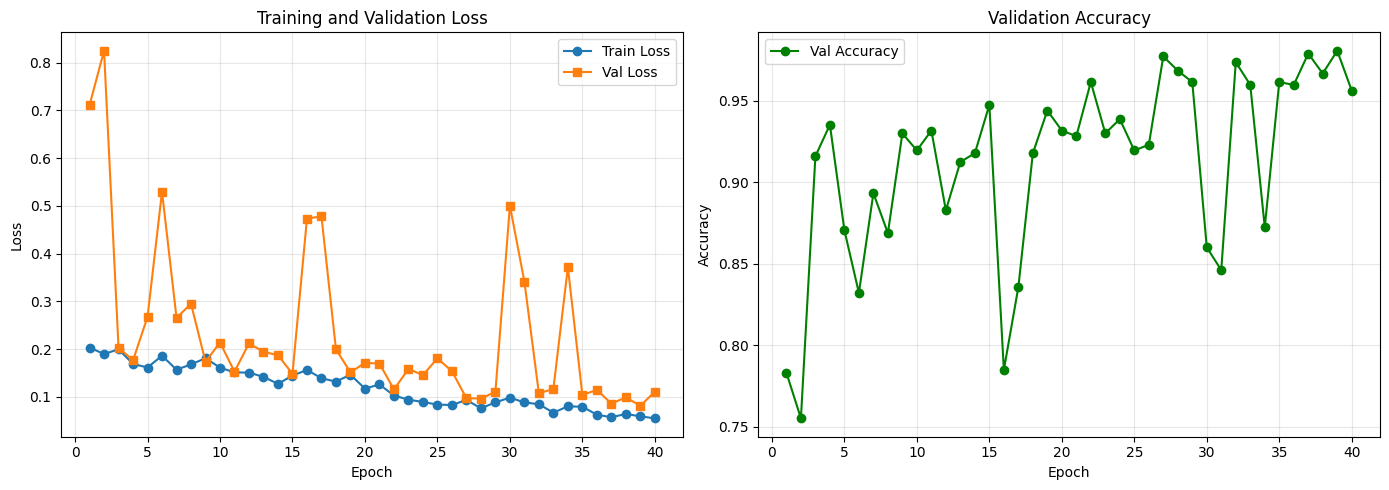


Final training loss: 0.0551
Final validation loss: 0.1111
Final validation accuracy: 0.9563


In [32]:
# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(range(1, NUM_EPOCHS + 1), train_losses, label='Train Loss', marker='o')
axes[0].plot(range(1, NUM_EPOCHS + 1), val_losses, label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(range(1, NUM_EPOCHS + 1), val_accuracies, label='Val Accuracy', marker='o', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFinal training loss: {train_losses[-1]:.4f}")
print(f"Final validation loss: {val_losses[-1]:.4f}")
print(f"Final validation accuracy: {val_accuracies[-1]:.4f}")

## 7. Sanity Checks

Visualize predictions on random validation samples to verify the model is learning meaningful patterns.

In [33]:
# Select random validation samples
np.random.seed(42)
num_samples = 6
random_indices = np.random.choice(len(val_dataset), num_samples, replace=False)

print(f"Randomly selected {num_samples} validation samples for inspection:\n")

Randomly selected 6 validation samples for inspection:



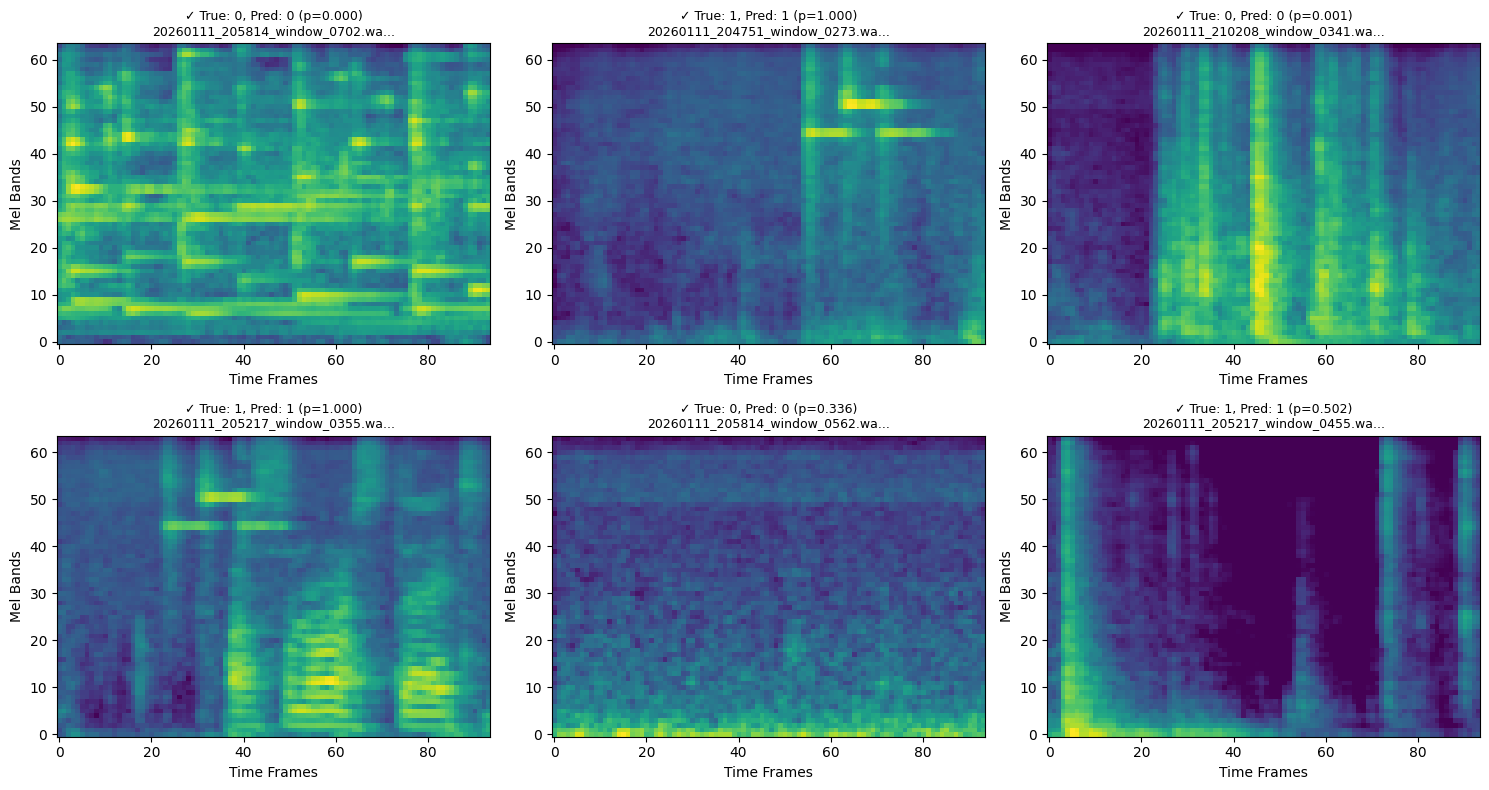

In [34]:
# Visualize samples with predictions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

model.eval()
with torch.no_grad():
    for i, idx in enumerate(random_indices):
        # Get sample
        spectrogram, label = val_dataset[idx]
        
        # Get prediction
        spec_input = spectrogram.unsqueeze(0).to(DEVICE)
        output = model(spec_input)
        probability = torch.sigmoid(output).item()
        prediction = 1 if probability > 0.5 else 0
        
        # Get metadata
        sample_metadata = val_metadata.iloc[idx]
        filename = sample_metadata['filename']
        
        # Plot spectrogram
        spec_np = spectrogram.squeeze().numpy()
        axes[i].imshow(spec_np, aspect='auto', origin='lower', cmap='viridis')
        axes[i].set_xlabel('Time Frames')
        axes[i].set_ylabel('Mel Bands')
        
        # Title with prediction info
        true_label = int(label.item())
        correct = '✓' if prediction == true_label else '✗'
        
        axes[i].set_title(
            f"{correct} True: {true_label}, Pred: {prediction} (p={probability:.3f})\n"
            f"{filename[:30]}...",
            fontsize=9
        )

plt.tight_layout()
plt.show()

In [35]:
# Print detailed information for each sample
print("\nDetailed Sample Information:\n")
print("="*80)

model.eval()
with torch.no_grad():
    for i, idx in enumerate(random_indices):
        # Get sample
        spectrogram, label = val_dataset[idx]
        
        # Get prediction
        spec_input = spectrogram.unsqueeze(0).to(DEVICE)
        output = model(spec_input)
        probability = torch.sigmoid(output).item()
        prediction = 1 if probability > 0.5 else 0
        
        # Get metadata
        sample_metadata = val_metadata.iloc[idx]
        
        # Print info
        true_label = int(label.item())
        correct = '✓ CORRECT' if prediction == true_label else '✗ INCORRECT'
        
        print(f"Sample {i+1}:")
        print(f"  Filename:        {sample_metadata['filename']}")
        print(f"  Session ID:      {sample_metadata['session_id']}")
        print(f"  Window Index:    {sample_metadata['window_index']}")
        print(f"  Context:         {sample_metadata['context']}")
        print(f"  Ground Truth:    {true_label} ({'Glucose Alarm' if true_label == 1 else 'No Alarm'})")
        print(f"  Prediction:      {prediction} ({'Glucose Alarm' if prediction == 1 else 'No Alarm'})")
        print(f"  Probability:     {probability:.4f}")
        print(f"  Result:          {correct}")
        print("-"*80)

print("="*80)


Detailed Sample Information:

Sample 1:
  Filename:        20260111_205814_window_0702.wav
  Session ID:      20260111_205814
  Window Index:    702
  Context:         alarms
  Ground Truth:    0 (No Alarm)
  Prediction:      0 (No Alarm)
  Probability:     0.0000
  Result:          ✓ CORRECT
--------------------------------------------------------------------------------
Sample 2:
  Filename:        20260111_204751_window_0273.wav
  Session ID:      20260111_204751
  Window Index:    273
  Context:         no_background_noise
  Ground Truth:    1 (Glucose Alarm)
  Prediction:      1 (Glucose Alarm)
  Probability:     1.0000
  Result:          ✓ CORRECT
--------------------------------------------------------------------------------
Sample 3:
  Filename:        20260111_210208_window_0341.wav
  Session ID:      20260111_210208
  Window Index:    341
  Context:         background_noise
  Ground Truth:    0 (No Alarm)
  Prediction:      0 (No Alarm)
  Probability:     0.0010
  Result:  

## Summary

### Model Performance

This notebook demonstrates proof-of-learnability:
- The CNN can learn to distinguish glucose alarm windows from non-alarm windows
- Performance metrics indicate whether the model generalizes to unseen sessions

### Key Observations

1. **Training curves**: Check for overfitting (train loss << val loss)
2. **Confusion matrix**: Identify which class is harder to predict
3. **Sample predictions**: Verify the model is learning meaningful patterns

### Limitations

- This is a window-level classifier (no temporal aggregation)
- No post-processing or thresholding applied
- Limited to the sessions in the dataset

### Next Steps

1. **Compare window sizes**: Train models on different datasets (1.0s, 1.5s, 2.0s) and compare in `model_comparison.ipynb`
2. **Collect more data**: Record more sessions for better generalization
3. **Data augmentation**: Add time/frequency masking, noise injection
4. **Architecture tuning**: Experiment with different CNN architectures
5. **Temporal modeling**: Add LSTM or attention for sequence modeling
6. **Deployment**: Implement real-time inference with sliding windows

### Versioned Dataset Workflow

To experiment with different window sizes:
1. Create datasets with different parameters in `prepare_dataset.ipynb`
2. Update `DATASET_DIR` in this notebook to point to each dataset
3. Train a model on each dataset (unique models saved automatically)
4. Compare all models in `model_comparison.ipynb` to find the best window size

In [36]:
# Save final metrics
metrics_summary = {
    'final_train_loss': train_losses[-1],
    'final_val_loss': val_losses[-1],
    'final_val_accuracy': val_accuracies[-1],
    'best_val_loss': best_val_loss,
    'best_epoch': best_epoch,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1
}

print("\nFinal Metrics Summary:")
print("="*50)
for key, value in metrics_summary.items():
    print(f"{key:25s}: {value:.4f}")
print("="*50)

# Save comprehensive model metadata
import json
import platform

model_metadata = {
    # Model identification
    'model_name': MODEL_NAME,
    'timestamp': TIMESTAMP,
    'model_file': str(MODEL_SAVE_PATH.name),
    
    # Audio parameters
    'audio_params': {
        'sample_rate': SAMPLE_RATE,
        'window_length': WINDOW_LENGTH,
        'n_mels': N_MELS,
        'n_fft': N_FFT,
        'hop_length': HOP_LENGTH
    },
    
    # Training parameters
    'training_params': {
        'batch_size': BATCH_SIZE,
        'num_epochs': NUM_EPOCHS,
        'learning_rate': LEARNING_RATE,
        'optimizer': 'Adam',
        'loss_function': 'BCEWithLogitsLoss'
    },
    
    # Dataset information
    'dataset_info': {
        'dataset_path': str(DATASET_DIR),
        'dataset_name': DATASET_DIR.name,
        'total_samples': len(metadata),
        'train_samples': len(train_metadata),
        'val_samples': len(val_metadata),
        'train_class_0': int((train_metadata['label'] == 0).sum()),
        'train_class_1': int((train_metadata['label'] == 1).sum()),
        'val_class_0': int((val_metadata['label'] == 0).sum()),
        'val_class_1': int((val_metadata['label'] == 1).sum())
    },
    
    # Performance metrics
    'metrics': {
        'accuracy': float(accuracy),
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'best_val_loss': float(best_val_loss),
        'best_epoch': int(best_epoch),
        'final_train_loss': float(train_losses[-1]),
        'final_val_loss': float(val_losses[-1]),
        'final_val_accuracy': float(val_accuracies[-1])
    },
    
    # Confusion matrix
    'confusion_matrix': {
        'true_negatives': int(cm[0, 0]),
        'false_positives': int(cm[0, 1]),
        'false_negatives': int(cm[1, 0]),
        'true_positives': int(cm[1, 1])
    },
    
    # Training history
    'training_history': {
        'train_losses': [float(x) for x in train_losses],
        'val_losses': [float(x) for x in val_losses],
        'val_accuracies': [float(x) for x in val_accuracies]
    },
    
    # System information
    'system_info': {
        'device': str(DEVICE),
        'platform': platform.platform(),
        'python_version': platform.python_version(),
        'pytorch_version': torch.__version__
    }
}

# Save metadata to JSON file
with open(MODEL_METADATA_PATH, 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f"\n✓ Model metadata saved to: {MODEL_METADATA_PATH}")

# Also append to a master log file for easy comparison
MASTER_LOG_PATH = MODELS_DIR / 'training_log.jsonl'
with open(MASTER_LOG_PATH, 'a') as f:
    f.write(json.dumps(model_metadata) + '\n')

print(f"✓ Training log updated: {MASTER_LOG_PATH}")


Final Metrics Summary:
final_train_loss         : 0.0551
final_val_loss           : 0.1111
final_val_accuracy       : 0.9563
best_val_loss            : 0.0813
best_epoch               : 39.0000
accuracy                 : 0.9808
precision                : 0.9825
recall                   : 0.9790
f1_score                 : 0.9807

✓ Model metadata saved to: models/glucose_alarm_cnn_w1.5s_20260315_132646_continued_metadata.json
✓ Training log updated: models/training_log.jsonl
